In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent
sys.path.append(str(PROJECT_DIR))
print(PROJECT_DIR)

/home/nhrot/Prog/tesis-primate


In [2]:
import os
import random

import cv2
import librosa
import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.core.config import settings, update_path_settings
from src.domain.pipelines.annotations import (
    load_annotation_file,
    get_annotation_file,
    df_to_annotations,
    clip_annotations_to_window,
)
from src.domain.pipelines.audio import (
    torchaudio_load_audio_file,
    apply_pitch_shift,
    apply_time_stretch,
)
from src.domain.pipelines.image import (
    calc_spec_shape,
    map_annotations_to_pixels,
    wav_to_spec,
    apply_visual_augmentations,
)
from src.domain.utils.species import get_species_id

update_path_settings(project_dir=PROJECT_DIR)

DATA_RAW_DIR = settings.DATA_RAW_DIR or Path("data/raw")
DATA_PREPROCESSED_DIR = settings.DATA_PREPROCESSED_DIR or Path("data/preprocessed")

In [13]:
specie_dirs = [d for d in DATA_RAW_DIR.iterdir() if d.is_dir()]
sample_specie_dir = random.choice(specie_dirs)
sample_specie_dir

PosixPath('/home/nhrot/Prog/tesis-primate/data/raw/weddells_saddleBack_tamarin__LW')

In [23]:
records_files = list(sample_specie_dir.glob("**/*.wav"))
sample_record = random.choice(records_files)

rel_path = sample_record.relative_to(DATA_RAW_DIR)
annotations_dir = (DATA_PREPROCESSED_DIR / rel_path).parent
sample_annotation = get_annotation_file(annotations_dir, sample_record)
if sample_annotation is None:
    raise FileNotFoundError(f"No annotation file found for {sample_record}")
annotation_df = load_annotation_file(sample_annotation)
print(f"Sample record: {sample_record}")
print(f"Number of annotations: {len(annotation_df)}")
annotation_df.head()

Sample record: /home/nhrot/Prog/tesis-primate/data/raw/weddells_saddleBack_tamarin__LW/20240214_101527.wav
Number of annotations: 6


,specie,call_type,begin_time,end_time,low_freq,high_freq,duration_s,bandwidth_hz
0,lw,cc,1.812,4.672,8368.4,11689.2,2.860,3320.8
1,lw,cs,1.834,2.325,9028.3,11053.9,0.491,2025.6
2,lw,cs,2.467,2.915,9223.5,11529.4,0.448,2305.9
3,lw,cs,3.079,3.559,9007.4,11313.2,0.480,2305.8
4,lw,cs,3.734,4.159,9007.4,11097.1,0.425,2089.7


Audio duration (seconds): 10.43
Spectrogram shape: torch.Size([2049, 2575])


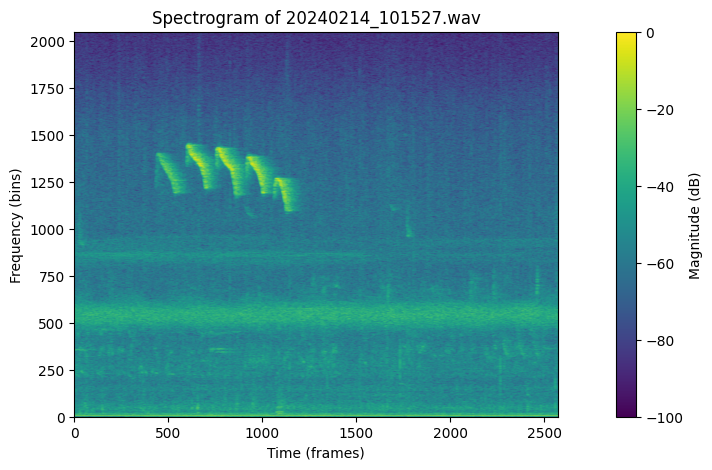

In [25]:
SAMPLE_RATE = 32000
NFFT = 4096
HOP_LENGTH = 128

wav_tensor = torchaudio_load_audio_file(sample_record, sample_rate=SAMPLE_RATE)
spec_tensor = wav_to_spec(wav_tensor, n_fft=NFFT, hop_length=HOP_LENGTH)
print(f"Audio duration (seconds): {wav_tensor.shape[0] / SAMPLE_RATE:.2f}")
print(f"Spectrogram shape: {spec_tensor.shape}")
# Plot the spectrogram
plt.figure(figsize=(15, 5))
plt.imshow(10 * np.log10(spec_tensor.numpy() + 1e-10), origin="lower")
plt.title(f"Spectrogram of {sample_record.name}")
plt.xlabel("Time (frames)")
plt.ylabel("Frequency (bins)")
plt.colorbar(label="Magnitude (dB)")
plt.show()

In [26]:
annotations = df_to_annotations(annotation_df)
px_boxes = map_annotations_to_pixels(
    annotations=annotations,
    sample_length=wav_tensor.shape[0],
    sample_rate=SAMPLE_RATE,
    nfft=NFFT,
    hop_length=HOP_LENGTH,
    class_mapping_fn=lambda x, _: get_species_id(x),
)

Spectrogram image shape: (2049, 2575)


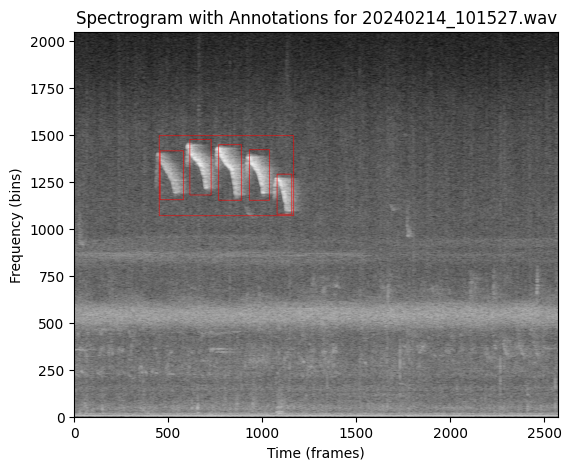

In [27]:
def spec_to_image(spec: torch.Tensor) -> npt.NDArray[np.uint8]:
    spec_db = 10 * np.log10(spec.numpy() + 1e-10)
    spec_db -= spec_db.min()
    spec_db /= spec_db.max()
    spec_img = (spec_db * 255).astype(np.uint8)
    return np.ascontiguousarray(spec_img)


spec_img = spec_to_image(spec_tensor)
boxed_spec_img = cv2.cvtColor(spec_img, cv2.COLOR_GRAY2RGB)
print(f"Spectrogram image shape: {spec_img.shape}")

plt.figure(figsize=(15, 5))
for box in px_boxes:
    class_id, x_min, y_min, x_max, y_max = box
    cv2.rectangle(
        boxed_spec_img,
        (x_min, y_min),
        (x_max, y_max),
        (255, 0, 0),
        2,
    )

plt.imshow(boxed_spec_img, origin="lower")
plt.title(f"Spectrogram with Annotations for {sample_record.name}")
plt.xlabel("Time (frames)")
plt.ylabel("Frequency (bins)")
plt.show()

In [28]:
start_sec = 3.5
duration_sec = 5.0
start_sample = int(start_sec * SAMPLE_RATE)
end_sample = start_sample + int(duration_sec * SAMPLE_RATE)
wav_clip = wav_tensor[start_sample:end_sample]

In [29]:
clip_annotations = clip_annotations_to_window(
    annotations=annotations,
    start_sec=start_sec,
    duration_sec=duration_sec,
)
clip_boxes = map_annotations_to_pixels(
    annotations=clip_annotations,
    sample_length=wav_clip.shape[0],
    sample_rate=SAMPLE_RATE,
    nfft=NFFT,
    hop_length=HOP_LENGTH,
    class_mapping_fn=lambda x, _: get_species_id(x),
)
clip_annotations

[AnnotationBox(specie='lw', call_type='cs', begin_time=0.23399999999999999, end_time=0.6589999999999998, low_freq=9007.4, high_freq=11097.1),
 AnnotationBox(specie='lw', call_type='cs', begin_time=0.8230000000000004, end_time=1.1289999999999996, low_freq=8430.9, high_freq=10088.2)]

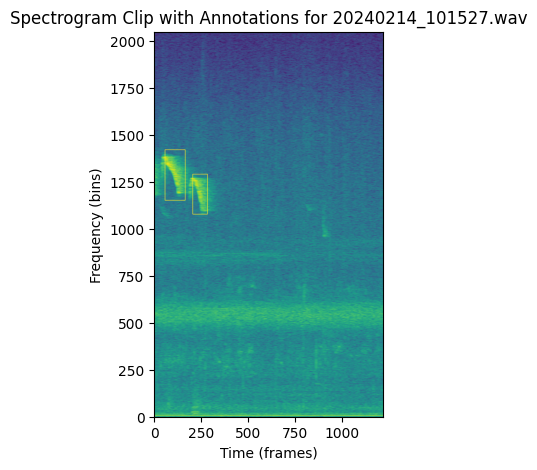

In [ ]:
spec_clip = wav_to_spec(wav_clip, n_fft=NFFT, hop_length=HOP_LENGTH)
spec_clip_img = spec_to_image(spec_clip)

for box in clip_boxes:
    class_id, x_min, y_min, x_max, y_max = box
    cv2.rectangle(
        spec_clip_img,
        (x_min, y_min),
        (x_max, y_max),
        (255, 0, 0),
        2,
    )
plt.figure(figsize=(15, 5))
plt.imshow(spec_clip_img, origin="lower")
plt.title(f"Spectrogram Clip with Annotations for {sample_record.name}")
plt.xlabel("Time (frames)")
plt.ylabel("Frequency (bins)")
plt.show()